Summary Statistics and Frequency Tables:

In [1]:
import pandas as pd
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen_2.xlsx", sheet_name='Sheet4')
# df.head()
df = df.rename(columns={'Entscheidung (Untrelassung)': 'Injunction'})
selected_columns = ['Aktenzeichen', 'Landgericht', 'Die Beklagte wird verurteilt zu unterlassen',
                    'Klage auf Unterlassung', 'Urteil', 'Prehuawei', 'First contact',
                    'Date of complaint', 'First licensing offer', 'Date of decision',
                    'Injunction', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially',
                     'Pool', 'Worldwide', 'Further proceedings']
df_sub = df.loc[:, selected_columns]
# # Removes Prehuawei and transition cases!!
# df_sub = df_sub[df_sub['Prehuawei'] != 1]
# This was deprecated for the second commit. The Prehuawei cases are now included in the analysis.

frand_defense = ['Injunction', 'Dominant position', 'Abuse of dominant position',
                     'Notice of Infringement', 'Willingness to license', 'FRAND offer', 'Formal', 'Substantially']
summary_stats = df_sub[frand_defense].describe(include='all').transpose()
print(summary_stats)

for column in df_sub.columns:
    if column != 'Injunction':
        freq_table = pd.crosstab(df_sub[column], df_sub['Injunction'], margins=True, margins_name='Total')
        print(f"\nFrequency Table for {column}:\n{freq_table}\n")


                           count unique           top freq
Injunction                    71      2           Yes   48
Dominant position             71      2           Yes   66
Abuse of dominant position    71      4            No   41
Notice of Infringement        71      3           Yes   69
Willingness to license        71      4            No   34
FRAND offer                   71      3           Yes   26
Formal                        71      5           Yes   27
Substantially                 71      4  Not assessed   39

Frequency Table for Aktenzeichen:
Injunction    No  Yes  Total
Aktenzeichen                
14d O 13/17    1    0      1
2 O 106/14     0    1      1
2 O 131/19     0    1      1
2 O 136/18     1    0      1
2 O 34/19      0    1      1
...           ..  ...    ...
7 O 8818/19    0    1      1
7 O 96/14      0    1      1
7 O 97/14      0    1      1
7 O 209/15     1    0      1
Total         23   48     71

[72 rows x 3 columns]


Frequency Table for Landgericht:

Bar charts

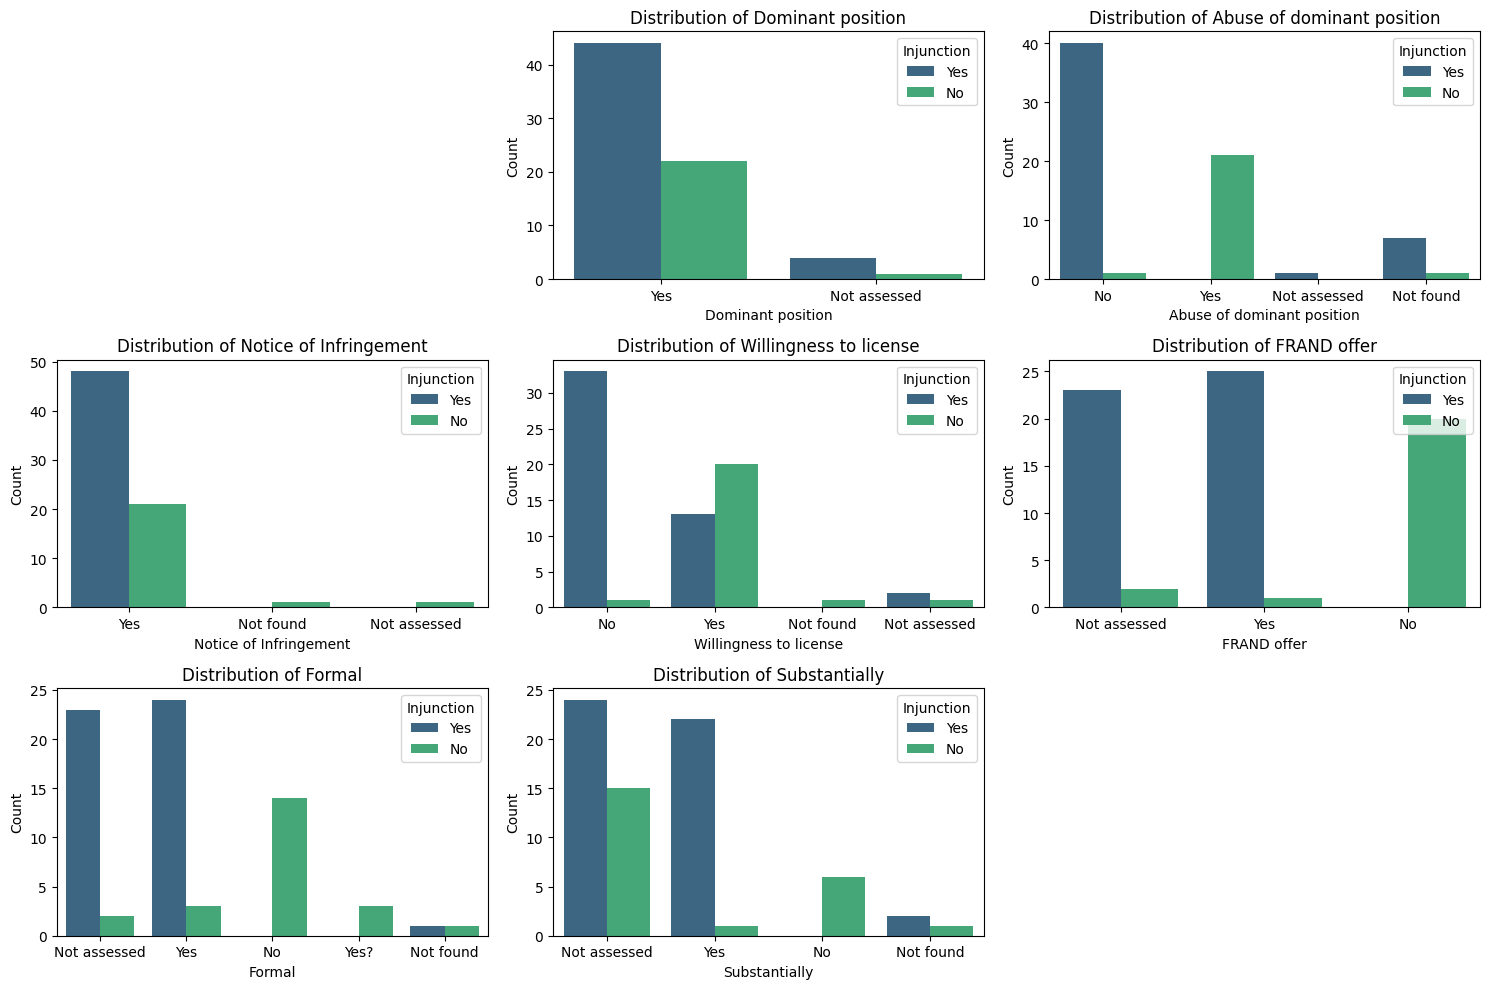

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df_frand_def = df_sub.loc[:, frand_defense]

plt.figure(figsize=(15, 10))
for i, column in enumerate(df_frand_def.columns):
    if column != 'Injunction':
        plt.subplot(3, 3, i + 1)
        sns.countplot(x=column, hue='Injunction', data=df_frand_def, palette='viridis')
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
plt.tight_layout()
plt.show()


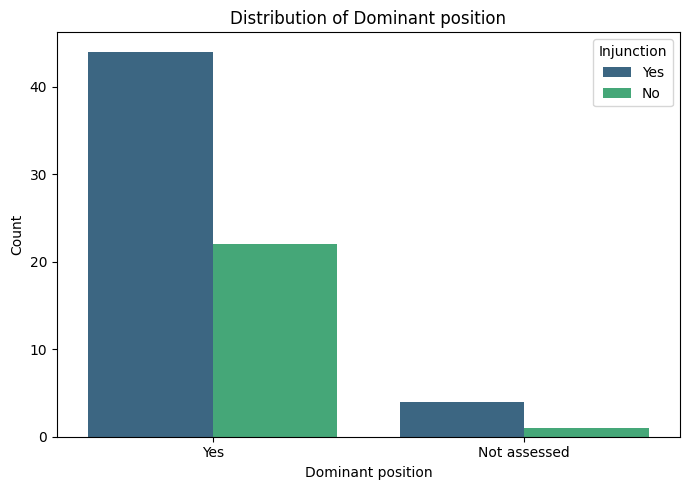

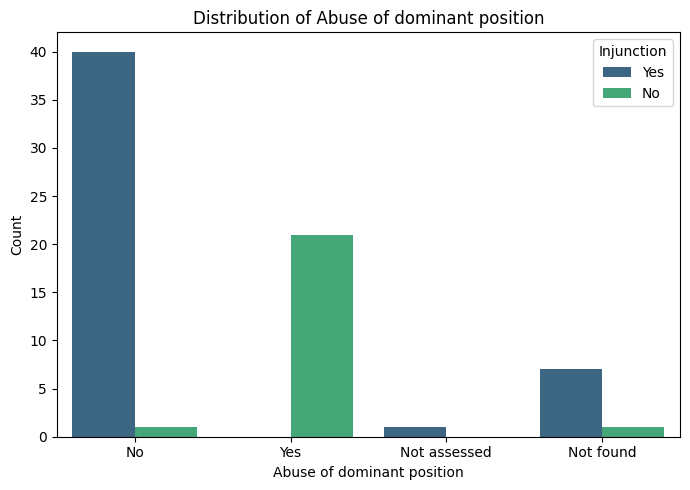

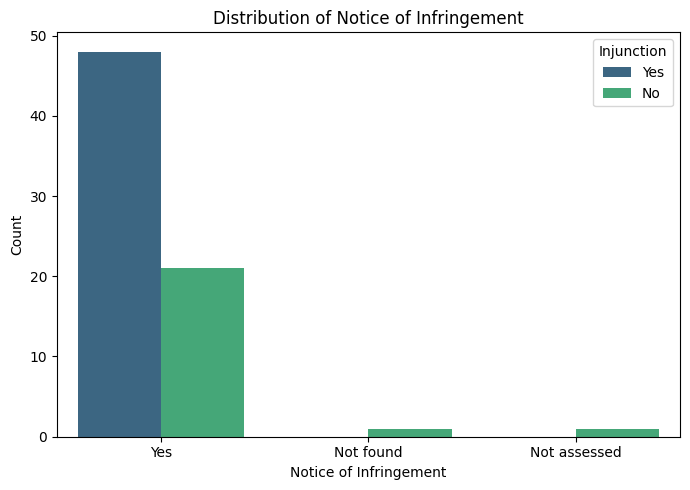

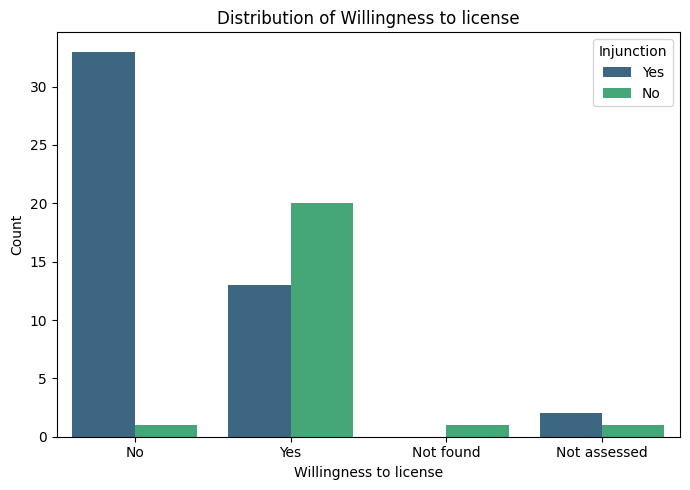

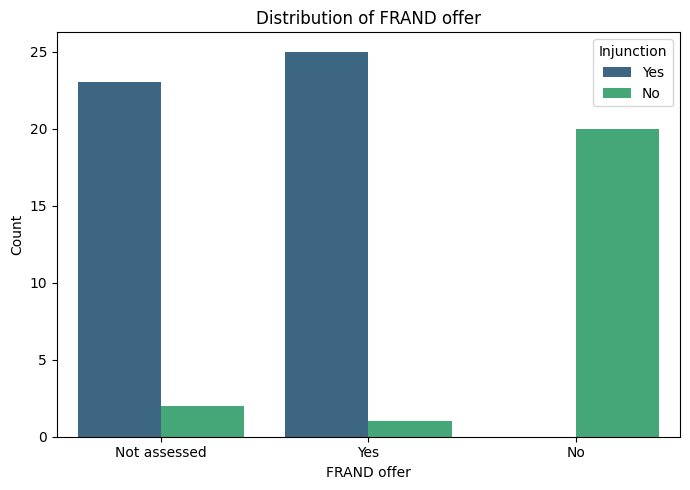

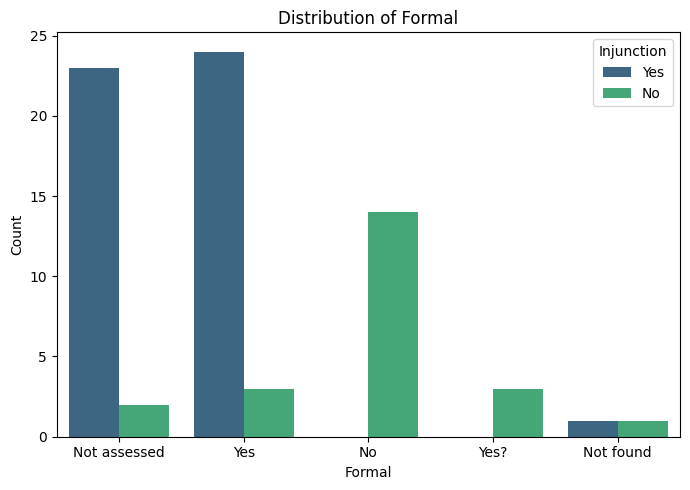

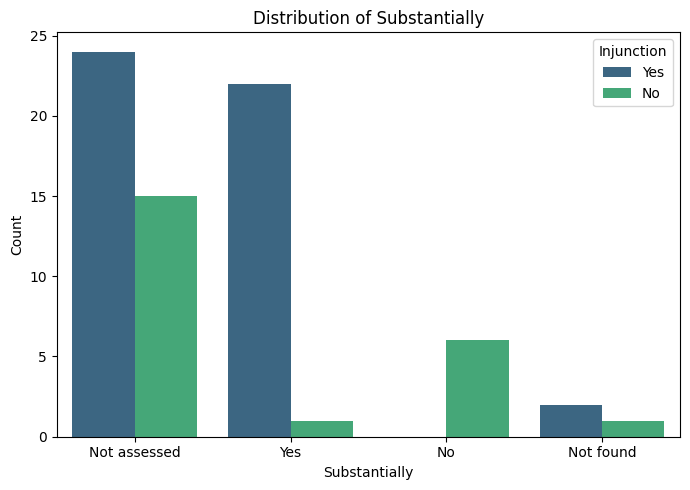

In [3]:
for i, column in enumerate(df_frand_def.columns):
    if column != 'Injunction':
        plt.figure(figsize=(7, 5))
        sns.countplot(x=column, hue='Injunction', data=df_frand_def, palette='viridis')
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        
        plt.tight_layout()
        # plt.savefig(f'{column}_distribution.png')  # Save each graph as an image
        plt.show()

Cross-Tabulation

In [4]:
for column in df_frand_def.columns:
    if column != 'Injunction':
        cross_tab = pd.crosstab(index=df_frand_def[column], columns=df_frand_def['Injunction'], margins=True, margins_name='Total')
        print(f"\nCross-Tabulation for {column}:\n{cross_tab}\n")



Cross-Tabulation for Dominant position:
Injunction         No  Yes  Total
Dominant position                
Not assessed        1    4      5
Yes                22   44     66
Total              23   48     71


Cross-Tabulation for Abuse of dominant position:
Injunction                  No  Yes  Total
Abuse of dominant position                
No                           1   40     41
Not assessed                 0    1      1
Not found                    1    7      8
Yes                         21    0     21
Total                       23   48     71


Cross-Tabulation for Notice of Infringement:
Injunction              No  Yes  Total
Notice of Infringement                
Not assessed             1    0      1
Not found                1    0      1
Yes                     21   48     69
Total                   23   48     71


Cross-Tabulation for Willingness to license:
Injunction              No  Yes  Total
Willingness to license                
No                       1   33

Chi-Square test

In [5]:
from scipy.stats import chi2_contingency

# Loop through each variable
for variable in frand_defense[1:]:  # Exclude 'Injunction' from the loop
    # Create a contingency table
    contingency_table = pd.crosstab(df_frand_def[variable], df_frand_def['Injunction'])

    # Perform Chi-square test
    chi2, p, _, _ = chi2_contingency(contingency_table)

    # Print the results
    print(f"\nChi-square test for {variable} vs. Injunction:")
    print(f"Chi-square value: {chi2}")
    print(f"P-value: {p}")

    # Interpret the results
    if p < 0.05:
        print("There is a significant association.")
    else:
        print("There is no significant association.")


Chi-square test for Dominant position vs. Injunction:
Chi-square value: 0.014080341458058858
P-value: 0.9055442410151647
There is no significant association.

Chi-square test for Abuse of dominant position vs. Injunction:
Chi-square value: 62.54988787999293
P-value: 1.676106467061804e-13
There is a significant association.

Chi-square test for Notice of Infringement vs. Injunction:
Chi-square value: 4.294896030245746
P-value: 0.11678180321435394
There is no significant association.

Chi-square test for Willingness to license vs. Injunction:
Chi-square value: 27.54857639696194
P-value: 4.517273887588256e-06
There is a significant association.

Chi-square test for FRAND offer vs. Injunction:
Chi-square value: 58.207830267558535
P-value: 2.292610386520713e-13
There is a significant association.

Chi-square test for Formal vs. Injunction:
Chi-square value: 48.13894323671497
P-value: 8.828897490249471e-10
There is a significant association.

Chi-square test for Substantially vs. Injunction

Correlation Heatmap

In [6]:
# 1. Heatmap correlation Diagram
# Convert categorical columns to numeric representations
df_numeric = df_frand_def.apply(lambda x: x.astype('category').cat.codes)

# # Display the numerical representation of each category
# for column in df_numeric.columns:
#     unique_categories = df_frand_def[column].astype('category').cat.categories
#     code_mapping = dict(zip(unique_categories, range(len(unique_categories))))
#     print(f"Mapping for {column}:\n{code_mapping}\n")

#FIND A BETTER WAY TO CONVERT THEM TO NUMBERS
mapping_one = {'Yes' : 2, 'No' : -2, 'n./a.' : 0, '-' : 0, '?' : 0}
mapping_two = {'Yes' : 2, 'No' : -2, '-' : 1, '?' : 0, 'Yes?' : 1}
mapping_three = {'Yes' : 2, 'No' : -2, '-' : -1, '?' : 0}

# print(df_numeric.dtypes)

# Apply the mapping to the columns
df_numeric = df_frand_def.replace({
    'Injunction': mapping_one,
    'Dominant position': mapping_one,
    'Abuse of dominant position': mapping_one,
    'Notice of Infringement': mapping_one,
    'Willingness to license': mapping_one,
    'FRAND offer': mapping_one,
    'Formal': mapping_two,
    'Substantially': mapping_three
})

# Create a correlation heatmap with the numeric DataFrame
df_numeric.head()
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


ValueError: could not convert string to float: 'Not assessed'

<Figure size 800x600 with 0 Axes>

Flow Chart

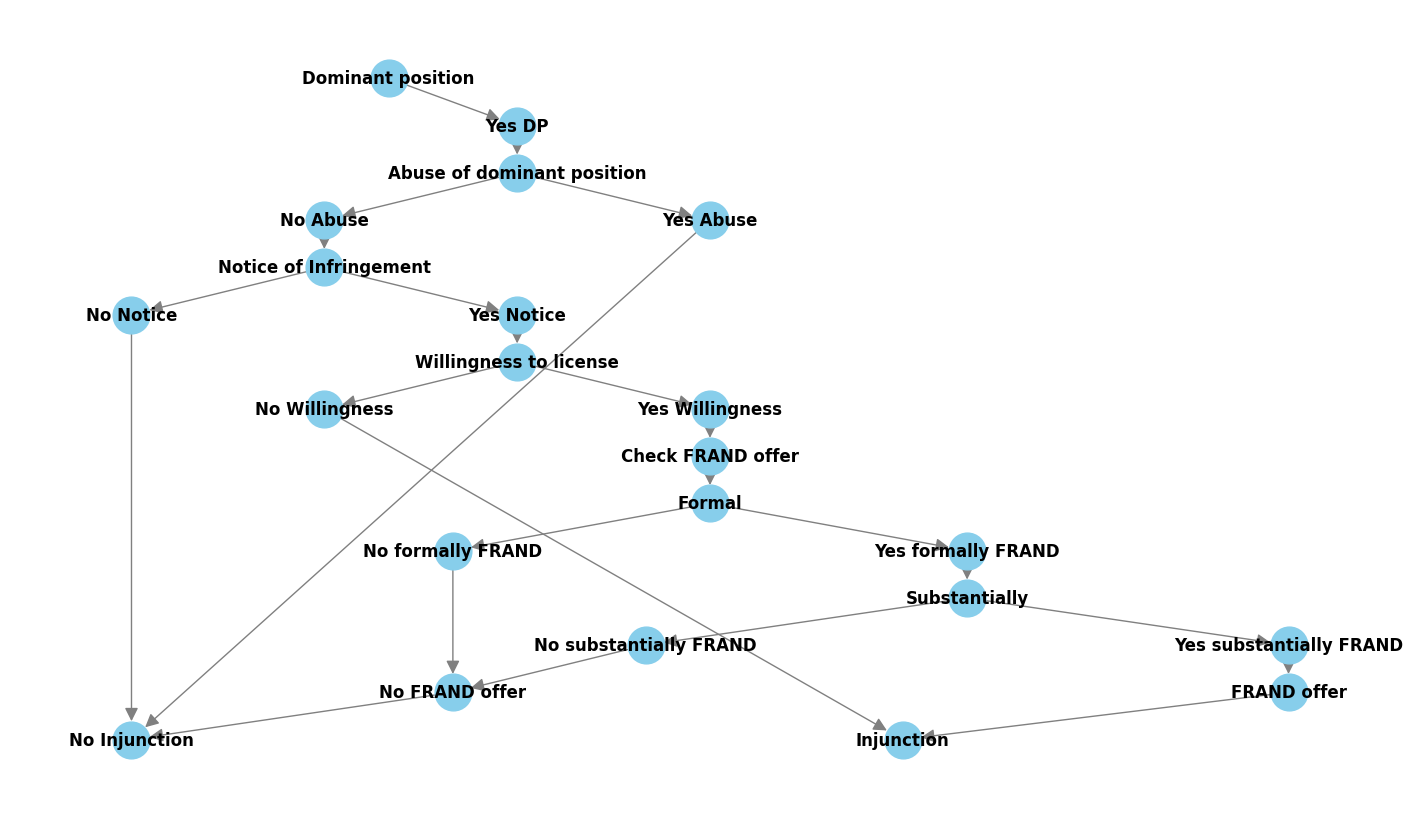

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
# import pydotplus
# import pygraphviz as pgv
# from networkx.drawing.nx_pydot import graphviz_layout

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges based on the decision tree structure
edges = [
    ('Dominant position', 'Yes DP'), ('Yes DP', 'Abuse of dominant position'),
    ('Abuse of dominant position', 'Yes Abuse'), ('Yes Abuse', 'No Injunction'),
    ('Abuse of dominant position', 'No Abuse'), ('No Abuse', 'Notice of Infringement'), 
    ('Notice of Infringement', 'No Notice'), ('No Notice', 'No Injunction'),
    ('Notice of Infringement', 'Yes Notice'), ('Yes Notice', 'Willingness to license'),
    ('Willingness to license', 'No Willingness'), ('No Willingness', 'Injunction'),
    ('Willingness to license', 'Yes Willingness'), ('Yes Willingness', 'Check FRAND offer'),
    ('Check FRAND offer', 'Formal'),
    ('Formal', 'No formally FRAND'), ('No formally FRAND', 'No FRAND offer'),
    ('Formal', 'Yes formally FRAND'), ('Yes formally FRAND', 'Substantially'),
    ('Substantially', 'No substantially FRAND'), ('No substantially FRAND', 'No FRAND offer'),
    ('Substantially', 'Yes substantially FRAND'), ('Yes substantially FRAND', 'FRAND offer'),
    ('No FRAND offer', 'No Injunction'), 
    ('FRAND offer', 'Injunction')
]

G.add_edges_from(edges)

# Create levels for nodes with both Y and X coordinates
levels = {
    'Dominant position': (0, 0),
    'Yes DP': (1, 2),
    'Abuse of dominant position': (2, 2),
    'Yes Abuse': (3, 5),
    'No Abuse': (3, -1),
    'Notice of Infringement': (4, -1),
    'No Notice': (5, -4),
    'Yes Notice': (5, 2),
    'Willingness to license': (6, 2),
    'No Willingness': (7, -1),
    'Yes Willingness': (7, 5),
    'Check FRAND offer': (8, 5),
    'Formal': (9, 5),
    'No formally FRAND': (10, 1),
    'Yes formally FRAND': (10, 9),
    'Substantially': (11, 9),
    'No substantially FRAND': (12, 4),
    'Yes substantially FRAND': (12, 14),
    'FRAND offer': (13, 14),
    'No FRAND offer': (13, 1),
    'Injunction': (14, 8),
    'No Injunction': (14, -4),
}

# Assign coordinates based on levels and specified x-coordinates
offset = 2
pos = {node: (coord[1], -coord[0] * offset) for node, coord in levels.items()}

# Adjust the size of the plot
plt.figure(figsize=(14, 8))

# Draw the graph
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, node_color='skyblue', font_color='black', 
        arrowsize=20, edge_color='grey')

plt.show()


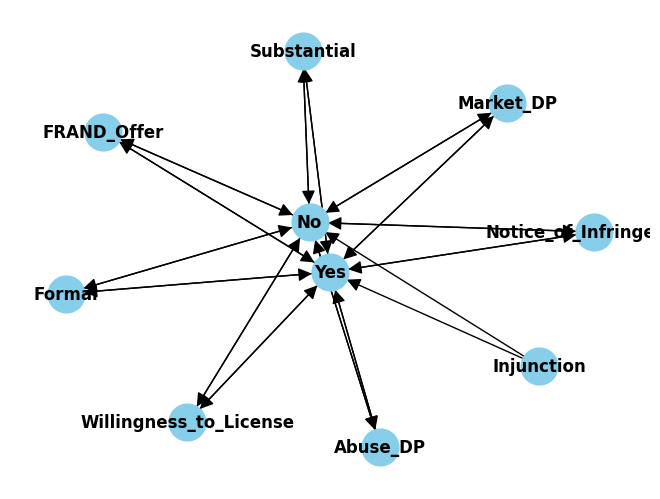

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Read your CSV file
df = pd.read_excel("C:\\Users\\berga\\Dropbox\\Espacio familiar\\Back-end\\Data library\\Judicial_documents\\DE_Germany\\Aktenzeichen.xlsx", sheet_name='Sheet4')


# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges based on the decision tree structure
edges = [
    ('Injunction', 'Yes'), ('Injunction', 'No'),
    ('Yes', 'Market_DP'), ('No', 'Market_DP'), ('Market_DP', 'Yes'), ('Market_DP', 'No'),
    ('Yes', 'Abuse_DP'), ('No', 'Abuse_DP'), ('Abuse_DP', 'Yes'), ('Abuse_DP', 'No'),
    ('Yes', 'Notice_of_Infringement'), ('No', 'Notice_of_Infringement'), ('Notice_of_Infringement', 'Yes'), ('Notice_of_Infringement', 'No'),
    ('Yes', 'Willingness_to_License'), ('No', 'Willingness_to_License'), ('Willingness_to_License', 'Yes'), ('Willingness_to_License', 'No'),
    ('Yes', 'FRAND_Offer'), ('No', 'FRAND_Offer'), ('FRAND_Offer', 'Yes'), ('FRAND_Offer', 'No'),
    ('Yes', 'Formal'), ('No', 'Formal'), ('Formal', 'Yes'), ('Formal', 'No'),
    ('Yes', 'Substantial'), ('No', 'Substantial'), ('Substantial', 'Yes'), ('Substantial', 'No'),
]

G.add_edges_from(edges)

# Draw the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, node_color='skyblue', font_color='black', arrowsize=20)

plt.show()

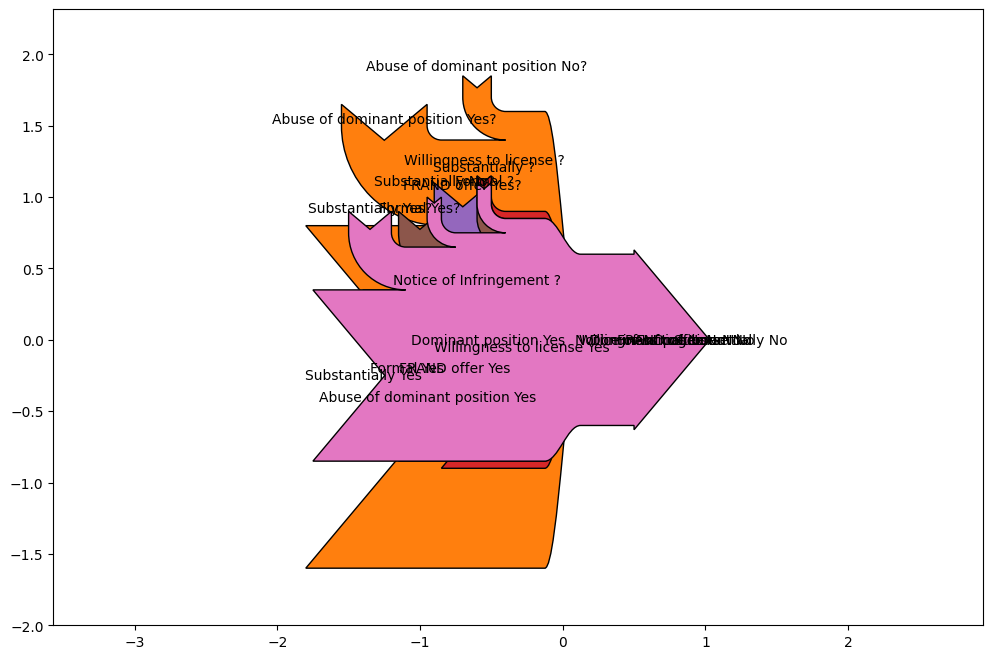

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey

# Define the cross-tabulation data
cross_tabs = {
    'Dominant position': {'No': 1, 'Yes': 3, 'n./a.': 0},
    'Abuse of dominant position': {'No': 0, 'Yes': 24, 'n./a.': 0, 'No?': 2, 'Yes?': 6},
    'Notice of Infringement': {'No': 1, 'Yes': 0, 'n./a.': 0, '?': 2},
    'Willingness to license': {'No': 1, 'Yes': 17, 'n./a.': 0, '?': 1},
    'FRAND offer': {'No': 2, 'Yes': 13, 'n./a.': 0, '?': 0, 'Yes?': 4},
    'Formal': {'No': 2, 'Yes': 11, 'n./a.': 0, '?': 1, 'Yes*': 0, 'Yes?': 3},
    'Substantially': {'No': 12, 'Yes': 12, 'n./a.': 0, '?': 1, 'No?': 1, 'Yes?': 3},
}

# Create a Sankey diagram
fig, ax = plt.subplots(figsize=(12, 8))

# Initialize Sankey
sankey = Sankey(ax=ax, unit=None, format='%d', scale=0.1, gap=0.25)

# Add flows for each step
for step, counts in cross_tabs.items():
    sankey.add(flows=[-counts['No'], counts['Yes'], counts['n./a.'], counts.get('?', 0), counts.get('No?', 0), counts.get('Yes?', 0)],
                labels=[f"{step} No", f"{step} Yes", f"{step} n./a.", f"{step} ?", f"{step} No?", f"{step} Yes?"],
                orientations=[0, 0, 0, 1, 1, 1],
                pathlengths=[0.25, 0.25, 0.25, 0.25, 0.25, 0.25],
                trunklength=1.0)

# Adjust margins
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-6, 6)

# Show the diagram
sankey.finish()
plt.show()
